Merge positive and negative over time.


=== Merged DataFrame (first 5 rows) ===
   time_ps  angle_chain1  angle_chain2  angle_chain3  angle_chain4  \
0      0.0        89.738        79.068        83.310        67.850   
1     50.0        85.690        88.298        85.350        68.600   
2    100.0        89.203        81.370        83.967        60.912   
3    150.0        88.344        80.083        86.072        58.348   
4    200.0        85.305        78.050        81.767        59.571   

   angle_chain5  angle_chain6  angle_chain7  angle_chain8  angle_chain9  \
0        69.097        65.618        81.214        76.540        85.898   
1        73.035        66.199        79.940        73.890        83.459   
2        74.188        72.725        78.228        76.830        82.115   
3        76.963        67.378        74.807        79.449        81.921   
4        77.182        64.330        73.548        79.971        82.685   

   angle_chain10  angle_chain11  angle_chain12  angle_chain13  angle_chain14  
0       

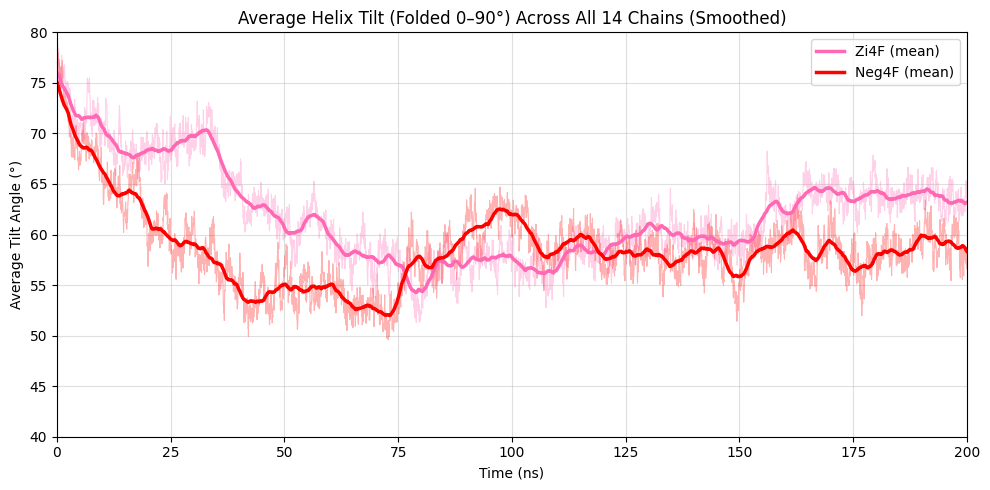

✅ Plot saved to: D:\OneDrive - Kent State University\mylaptop\Bicelle\PEP\analysis\analysis_03\merged02\zi4F_neg4F_angle_vs_time_smooth_fixed.pdf

Zi4F(75–200 ns): mean = 60.18°, std = 3.26°
Neg4F (75–200 ns): mean = 58.60°, std = 2.12°


In [43]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === Paths ===
pos_dir = r"D:\mylaptop\Bicelle\PEP\analysis\analysis_03\analysis_pos\analysis_positive_200ns"
neg_dir = r"D:\mylaptop\Bicelle\PEP\analysis\analysis_03\analysis_neg\analysis_negative_200ns"
save_file = r"D:\mylaptop\Bicelle\PEP\analysis\analysis_03\merged02\zi4F_neg4F_angle_vs_time_smooth_fixed.pdf"
save_file2 = r"D:\mylaptop\Bicelle\PEP\analysis\analysis_03\merged02\zi4F_neg4F_angle_vs_time_smooth_fixed.png"


# === Function to load and fold angles ===
def load_folded_avg(base_dir):
    all_dfs = []        #        # Create an empty list to store one DataFrame per chain (14 chains total)
    for chain in range(1, 15):   # Loop through chain numbers 1 to 14
        
        # Build the full path to the file for this chain
        # Example: base_dir + "chain3_tilt_vsZ.xvg"
        filepath = os.path.join(base_dir, f"chain{chain}_tilt_vsZ.xvg")         #It takes pieces of a file path and joins them correctly,
        
        # Open the .xvg file and read lines.
            # Keep only the lines that:
            #   - do NOT start with '#' (comments)
            #   - do NOT start with '@' (metadata)
            #   - are NOT empty
        with open(filepath) as f:
            lines = [line for line in f if not line.startswith(('#', '@')) and line.strip()]
        
        # Convert each line into a list of numbers (float)
        # Example: "0 45.3" → [0.0, 45.3]
        data_lines = [[float(x) for x in line.split()] for line in lines]
        
        
        # Create a DataFrame with two columns:
        #   - time_ps
        #   - angle_chainX  where X is the chain number
        df = pd.DataFrame(data_lines, columns=["time_ps", f"angle_chain{chain}"])
        #print("Before folding:\n", df.head())
        
        
        # Fold angles above 90 degrees into the 0–90 range
        # If angle <= 90 → keep it
        # If angle > 90 → convert to (180 - angle)
        # Fold 180° → 0–90°
        df[f"angle_chain{chain}"] = df[f"angle_chain{chain}"].apply(lambda a: a if a <= 90 else 180 - a)
        
        
        # Add this chain's DataFrame into the list
        all_dfs.append(df)
    
    
    # Start merging using the first chain's DataFrame
    merged_df = all_dfs[0]
    
    
    
    # Merge all other DataFrames into the first one by time_ps
    for df in all_dfs[1:]:
        # Merge on "time_ps" column
        merged_df = pd.merge(merged_df, df, on="time_ps", how="outer")
    ####################################################################
    #################Check merged DataFrame#############################
    ####################################################################
    print("\n=== Merged DataFrame (first 5 rows) ===")
    print(merged_df.head())
    

    ####################################################################
    ####################################################################
    
    # Collect the names of all angle columns (angle_chain1, angle_chain2, ...)
    angle_cols = [c for c in merged_df.columns if c.startswith("angle_chain")]
    
    
    # Average the angle values across all chains
    merged_df["avg_tilt"] = merged_df[angle_cols].mean(axis=1)
    print(merged_df.head())
    system_name = os.path.basename(base_dir)
    merged_df.to_csv(f"{system_name}_merged.csv", index=False)
    
    
    
    # Return the final DataFrame containing:
    # time_ps, angle_chain1..14, avg_tilt
    return merged_df



# === Load both systems ===
pos_df = load_folded_avg(pos_dir)
neg_df = load_folded_avg(neg_dir)

# === Smooth using rolling mean (edge-safe) ===
total_time_ns = 200
n_frames = len(pos_df)
smooth_window_ns = 5
window = int((smooth_window_ns / total_time_ns) * n_frames)
print(f"Smoothing window: {window} frames (~{smooth_window_ns} ns)")

pos_df["smooth_tilt"] = pos_df["avg_tilt"].rolling(window, center=True, min_periods=1).mean()
neg_df["smooth_tilt"] = neg_df["avg_tilt"].rolling(window, center=True, min_periods=1).mean()

# === Plot ===
plt.figure(figsize=(10, 5))
plt.plot(pos_df["time_ps"]/1000, pos_df["avg_tilt"], color="#FF69B4", lw=0.8, alpha=0.3)
plt.plot(neg_df["time_ps"]/1000, neg_df["avg_tilt"], color="#ff0000", lw=0.8, alpha=0.3)
plt.plot(pos_df["time_ps"]/1000, pos_df["smooth_tilt"], color="#FF69B4", lw=2.5, label="Zi4F (mean)")
plt.plot(neg_df["time_ps"]/1000, neg_df["smooth_tilt"], color="#ff0000", lw=2.5, label="Neg4F (mean)")
plt.xlabel("Time (ns)")
plt.ylabel("Average Tilt Angle (°)")
plt.title("Average Helix Tilt (Folded 0–90°) Across All 14 Chains (Smoothed)")
plt.legend()
plt.ylim(40, 80)
plt.xlim(0, 200)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.savefig(save_file, dpi=300)
plt.savefig(save_file2, dpi=300)
plt.show()

print("✅ Plot saved to:", save_file)
#+++++++++++++++++++++++++++++++++++++++
# === Mean and Std for 75–200 ns ===
#+++++++++++++++++++++++++++++++++++
# Select only the rows where time is between 100,000 ps and 200,000 ps
# (75 ns, 200 ns)
pos_window = pos_df[(pos_df["time_ps"] >= 75000) & (pos_df["time_ps"] <= 200000)]
neg_window = neg_df[(neg_df["time_ps"] >= 75000) & (neg_df["time_ps"] <= 200000)]


# Print the mean and standard deviation for the positive system
# pos_window['avg_tilt'].mean() → computes average tilt
# pos_window['avg_tilt'].std(ddof=1) → computes standard deviation
print(f"\nZi4F(75–200 ns): mean = {pos_window['avg_tilt'].mean():.2f}°, std = {pos_window['avg_tilt'].std(ddof=1):.2f}°")
print(f"Neg4F (75–200 ns): mean = {neg_window['avg_tilt'].mean():.2f}°, std = {neg_window['avg_tilt'].std(ddof=1):.2f}°")
